# Exploratory Data Analysis on Titanic Dataset

In [184]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [185]:
df= pd.read_csv("titanic_train.csv")

### Sample of Data

In [186]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
593,594,0,3,"Bourke, Miss. Mary",female,NaN,0,2,364848,7.7500,NaN,Q
651,652,1,2,"Doling, Miss. Elsie",female,18.0,0,1,231919,23.0000,NaN,S
540,541,1,1,"Crosby, Miss. Harriet R",female,36.0,0,2,WE/P 5735,71.0000,B22,S
50,51,0,3,"Panula, Master. Juha Niilo",male,7.0,4,1,3101295,39.6875,NaN,S
752,753,0,3,"Vande Velde, Mr. Johannes Joseph",male,33.0,0,0,345780,9.5000,NaN,S


### Shape of Data

In [187]:
df.shape

(891, 12)

##### It has 891 rows and 12 columns

### Column Names

In [188]:
df.columns.values

<ArrowStringArray>
['PassengerId',    'Survived',      'Pclass',        'Name',         'Sex',
         'Age',       'SibSp',       'Parch',      'Ticket',        'Fare',
       'Cabin',    'Embarked']
Length: 12, dtype: str

##### Categorical Columns
- Survived
- Pclass
- Sex
- SibSp
- Parch
- Embarked

##### Numerical Columns
- Age
- Fare
- PassengerId 

##### Mixed Columns
- Name
- Ticket
- Cabin


### Overview of Data

In [189]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


### Missing Data

In [190]:
null_values= df.isnull()
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Filling Missing Values 

In [191]:
# Imputing missing values of age with mean values
df.fillna({'Age':df['Age'].mean()}, inplace=True)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


In [192]:
# Imputing missing values of Embarked with most appeared values
print(df['Embarked'].value_counts())
df.fillna({'Embarked': 'S'}, inplace=True)

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


In [193]:
# Dropping Cabin Columns
df= df.drop(columns= ['Cabin'])
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C


In [194]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Changing data type

In [195]:
df['Survived']= df['Survived'].astype('category')
df['Pclass']= df['Pclass'].astype('category')
df['Sex']= df['Sex'].astype('category')
df['Age']= df['Age'].astype('int')
df['Embarked']= df['Embarked'].astype('category')

In [196]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    str     
 4   Sex          891 non-null    category
 5   Age          891 non-null    int64   
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
dtypes: category(4), float64(1), int64(4), str(2)
memory usage: 81.8 KB


In [197]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,29.544332,0.523008,0.381594,32.204208
std,257.353842,13.013778,1.102743,0.806057,49.693429
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,29.000000,0.000000,0.000000,14.454200
75%,668.500000,35.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


Survived
0    549
1    342
Name: count, dtype: int64


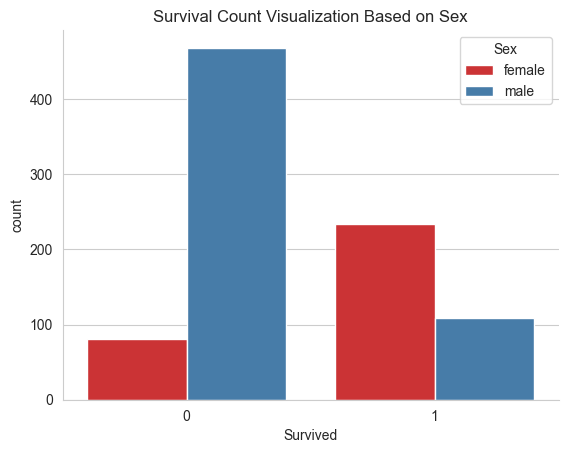

In [198]:
print(df['Survived'].value_counts())

plt.title("Survival Count Visualization Based on Sex")
sns.countplot(data= df, x= "Survived", hue= "Sex")
sns.despine()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


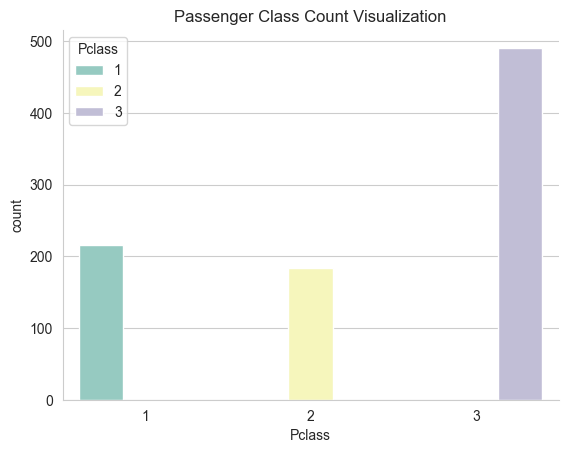

In [199]:
print(df['Pclass'].value_counts())

plt.title("Passenger Class Count Visualization")
sns.countplot(data= df, x= "Pclass", palette= "Set3", hue= "Pclass")
sns.despine()

Sex
male      577
female    314
Name: count, dtype: int64


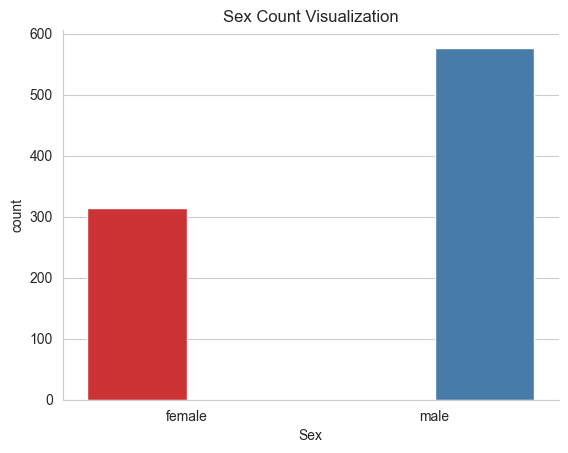

In [200]:
print(df['Sex'].value_counts())

plt.title("Sex Count Visualization")
sns.countplot(data= df, x= "Sex", hue= "Sex", palette="Set1")
sns.despine()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


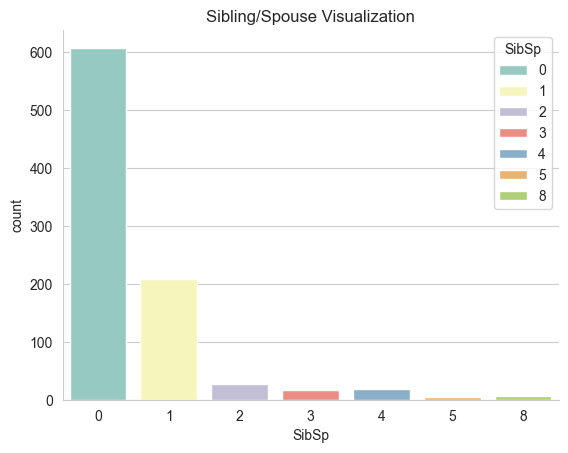

In [201]:
print(df['SibSp'].value_counts())

plt.title("Sibling/Spouse Visualization")
sns.countplot(data= df, x= "SibSp", hue= "SibSp", palette="Set3")
sns.despine()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


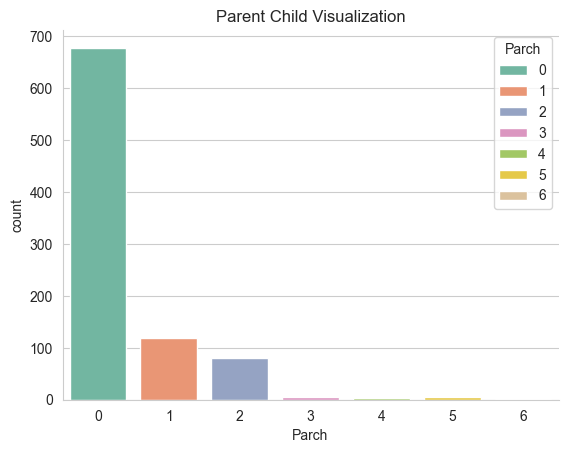

In [202]:
print(df['Parch'].value_counts())

plt.title("Parent Child Visualization")
sns.countplot(data= df, x= "Parch", hue= "Parch", palette="Set2")
sns.despine()

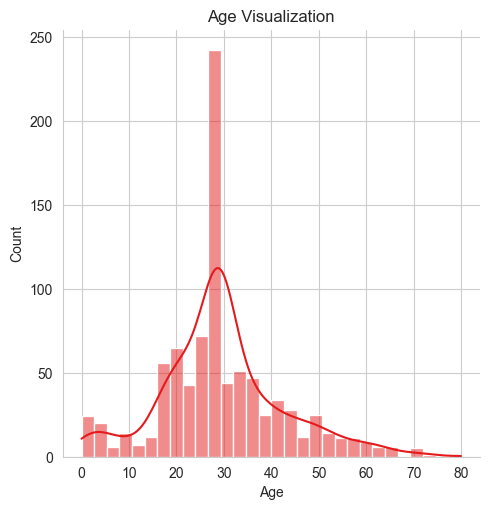

In [203]:
sns.displot(df['Age'], kde= True)
plt.title("Age Visualization")
sns.despine()

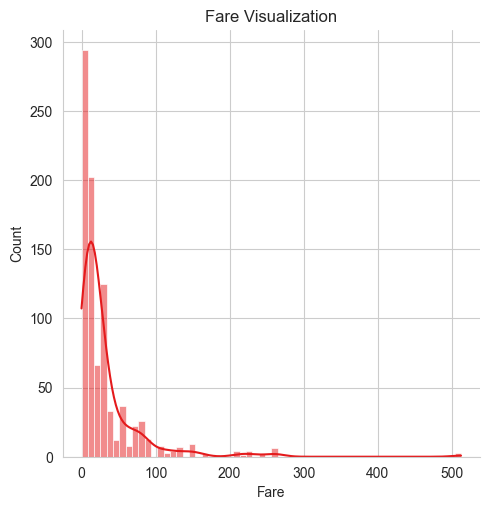

In [204]:
sns.displot(df['Fare'], kde= True)
plt.title("Fare Visualization")
sns.despine()

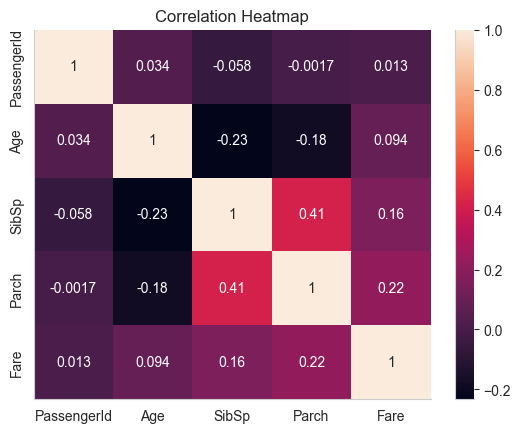

In [205]:
sns.heatmap(df.corr(numeric_only=True), annot= True)
plt.title("Correlation Heatmap")
sns.despine()

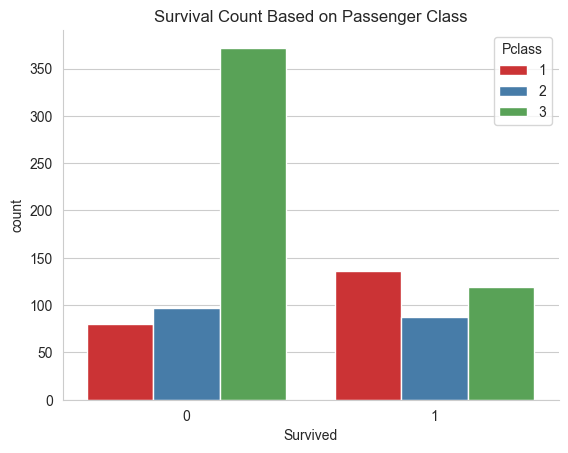

In [206]:
sns.countplot(data= df , x= "Survived", hue= "Pclass")
plt.title("Survival Count Based on Passenger Class")
sns.despine()

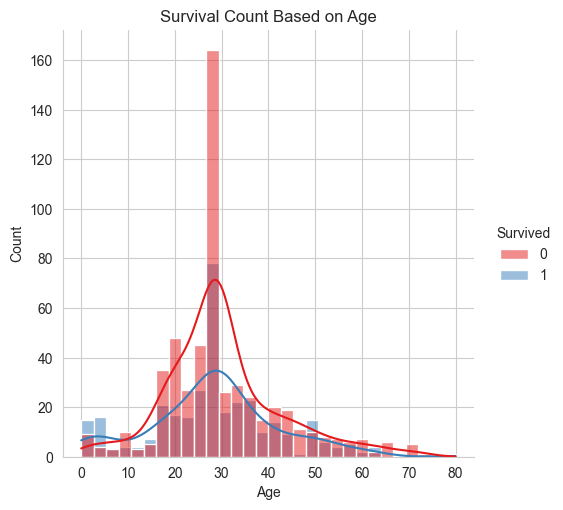

In [207]:
sns.displot(data= df, x= 'Age', hue= 'Survived', kde= True)
plt.title("Survival Count Based on Age")
sns.despine()

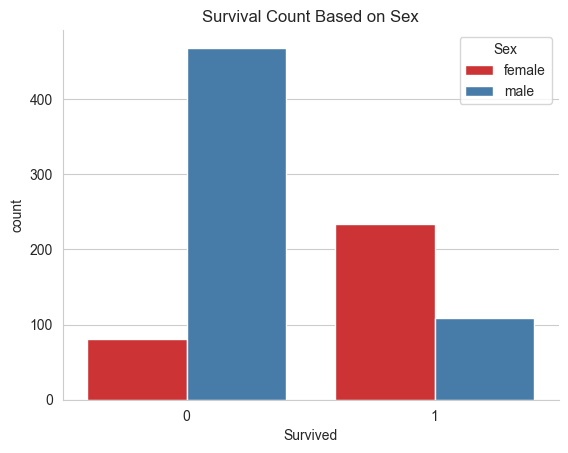

In [208]:
sns.countplot(data= df , x= 'Survived', hue= 'Sex')
plt.title("Survival Count Based on Sex")
sns.despine()